In [2]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from front_finding import buildconfig
from front_finding.cli import build_fronts
from front_finding.llc import source as llc_source

CONFIG = Path("../configs/run/small_fronts_dataset_00.yaml")
assert CONFIG.is_file(), f"run this from notebooks/ -- {CONFIG} not found"

cfg = buildconfig.load_config(CONFIG)

TIMESTAMP = cfg.timestamps[0]

In [3]:
cfg.finding

FindingConfig(build_version='SMALL_DATASET', config='D', gradb2_root='gradb2', suffix='sfc', ice_mask_find=False, ice_mask_props=False, properties_dilation_radius=2, properties_stats=['mean', 'std', 'min', 'max', 'skew'], properties_nan_policy='omit', properties_cross_front_radius=0, dilate_only_to_front_pixels=True, percentiles=[25, 75, 90], exclude_roots=[], save_unprocessed_binary=True, clobber={'find': False, 'group': False, 'colocate': False, 'push': False})

## Run

One call, four steps:

| step | does |
|---|---|
| `gradb2` | build `frontal_structure.zarr` if it is missing (a dbof run) |
| `find` | threshold gradb2 into a binary front map |
| `group` | label the fronts, measure their geometry |
| `colocate` | sample the subset's other 7 channels onto each front |

`frontal_structure` carries `gradb2, gradsalt2, gradtheta2, gradeta2,
gradrho2, turner_angle, density, buoyancy`, so `colocate` costs no extra
generation — every field is already in the store built by the first step, and
is read from it directly.

Drop steps from the list to re-run part of it.

In [4]:
#build_fronts.run(cfg, ["gradb2", "find", "group", "colocate"])
#build_fronts.run(cfg, ["colocate"])

build_fronts.run(cfg, ["push"])

pipeline=SURF  run_id=v2_2_01  dates=5  gradb2=gradb2 (subset=frontal_structure)  finding_config=D
steps=['push']
store -> /Users/jaketallman/PycharmProjects/front-finding/output/SMALL_DATASET/SURF/fronts.zarr
Publishing to s3://dbof/globals_for_cutouts/v2_2_01/Fronts/SMALL_DATASET/SURF/fronts.zarr
[20111216_030000]
  uploaded 1279 file(s)
[20120104_110000]
  uploaded 1277 file(s)
[20120208_230000]
  uploaded 1277 file(s)
Pushed 3833 file(s) across 3 snapshot(s)


front id: 77850
front 20111216TT030000_1.5S_70.0E   (label 77850)   20111216_030000
  4,712.3 km | 1,949 px | 241 branches | centroid -1.50, 69.96
labels: 
[     0      1      2 ... 127625 127626 127627]

--- geometry ---
label                                        77850
name                   20111216TT030000_1.5S_70.0E
time                           2011-12-16T03:00:00
npix                                          1949
y0                                            7673
y1                                            7975
x0                                            4862
x1                                            5599
centroid_lat                             -1.498694
centroid_lon                              69.95993
length_km                              4712.349609
orientation                               72.42337
num_branches                                   241
lat_min                                  -4.758078
lat_max                                    1.05478
lon_min      

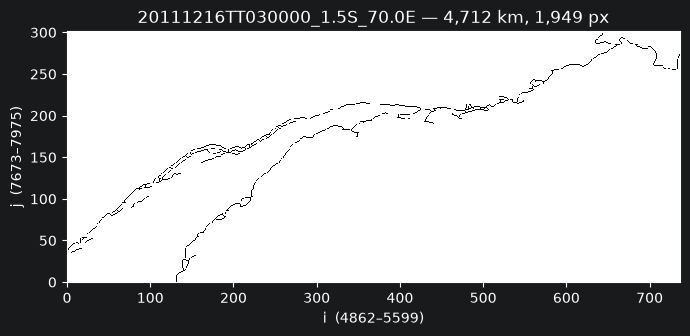

In [4]:
from front_finding.store import FrontStore

STORE = "../output/SMALL_DATASET/SURF/fronts.zarr"   # from notebooks/; adjust if elsewhere
LABEL = None                                   # None -> the longest front

store = FrontStore.open(STORE)
DATE = store.dates[0]

# --- pick the front --------------------------------------------------------
fronts = store.fronts(DATE, cross=True)                    # geometry joined to properties
if LABEL is None:
    LABEL = int(fronts.loc[fronts["length_km"].idxmax(), "label"])
print(f"front id: {LABEL}")
front = fronts[fronts["label"] == LABEL].iloc[0]

# geometry columns are whatever `group` wrote; the rest are {channel}_{stat}
geom_cols = list(store.geometry(DATE).columns)
STATS = ["mean", "std", "min", "max", "skew"]
prop_cols = [c for c in fronts.columns
             if c not in geom_cols and c.rsplit("_", 1)[-1] in STATS]

print(f"front {front['name']}   (label {LABEL})   {DATE}")
print(f"  {front['length_km']:,.1f} km | {int(front['npix']):,} px | "
      f"{front['num_branches']} branches | "
      f"centroid {front['centroid_lat']:.2f}, {front['centroid_lon']:.2f}")

print("labels: ")
print(np.unique(store.labels(DATE)))

# --- geometry --------------------------------------------------------------
print("\n--- geometry ---")
print(front[geom_cols].to_string())

# # --- properties, as channel x statistic ------------------------------------
print(f"\n--- properties ({len(prop_cols)} columns) ---")
table = pd.DataFrame({
    "channel": [c.rsplit("_", 1)[0] for c in prop_cols],
    "stat":    [c.rsplit("_", 1)[1] for c in prop_cols],
    "value":   front[prop_cols].astype(float).values,
}).pivot(index="channel", columns="stat", values="value")
print(table[list(STATS)].to_string(float_format=lambda v: f"{v:12.4g}"))

# gradients span ~1e-13 to 1e-7, so context matters when reading these
ca = store.step_attrs(DATE, "colocate")
print(f"\nsampled over each front dilated by {ca.get('properties_dilation_radius')} px, "
      f"nan_policy={ca.get('nan_policy')!r}")

# --- its pixels ------------------------------------------------------------
win = (int(front.y0), int(front.y1), int(front.x0), int(front.x1))
mask = store.labels(DATE, window=win) == LABEL   # reads only this window
print(f"\nbbox {win} -> {mask.shape} window, {int(mask.sum()):,} px are this front")

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(mask, origin="lower", cmap="Greys", interpolation="nearest")
ax.set_title(f"{front['name']} — {front['length_km']:,.0f} km, "
             f"{int(front['npix']):,} px")
ax.set_xlabel(f"i  ({win[2]}–{win[3]})")
ax.set_ylabel(f"j  ({win[0]}–{win[1]})")
fig.tight_layout()

In [5]:
print( list(store.fronts(DATE).columns) )

['label', 'name', 'time', 'npix', 'y0', 'y1', 'x0', 'x1', 'centroid_lat', 'centroid_lon', 'length_km', 'orientation', 'num_branches', 'lat_min', 'lat_max', 'lon_min', 'lon_max', 'mean_curvature', 'curvature_direction', 'npix_prop', 'gradb2_mean', 'gradb2_std', 'gradb2_min', 'gradb2_max', 'gradb2_skew', 'gradb2_p25', 'gradb2_p75', 'gradb2_p90', 'gradsalt2_mean', 'gradsalt2_std', 'gradsalt2_min', 'gradsalt2_max', 'gradsalt2_skew', 'gradsalt2_p25', 'gradsalt2_p75', 'gradsalt2_p90', 'gradtheta2_mean', 'gradtheta2_std', 'gradtheta2_min', 'gradtheta2_max', 'gradtheta2_skew', 'gradtheta2_p25', 'gradtheta2_p75', 'gradtheta2_p90', 'gradeta2_mean', 'gradeta2_std', 'gradeta2_min', 'gradeta2_max', 'gradeta2_skew', 'gradeta2_p25', 'gradeta2_p75', 'gradeta2_p90', 'gradrho2_mean', 'gradrho2_std', 'gradrho2_min', 'gradrho2_max', 'gradrho2_skew', 'gradrho2_p25', 'gradrho2_p75', 'gradrho2_p90', 'turner_angle_mean', 'turner_angle_std', 'turner_angle_min', 'turner_angle_max', 'turner_angle_skew', 'turner_

In [6]:
store.attrs

{'build_version': 'SMALL_DATASET',
 'pipeline': 'SURF',
 'run_id': 'v2_2_01',
 'config_file': '/Users/jaketallman/PycharmProjects/front-finding/configs/run/small_fronts_dataset_00.yaml',
 'source_bucket': 'dbof/',
 'source_folder': 'globals_for_cutouts/',
 'finding_config': 'D',
 'gradb2_channel': 'gradb2',
 'gradb2_subset': 'frontal_structure',
 'dates': ['2011-12-16 03:00:00',
  '2012-01-04 11:00:00',
  '2012-02-08 23:00:00',
  '2012-03-19 10:00:00',
  '2012-08-11 04:00:00']}

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy.stats import kurtosis, yeojohnson, yeojohnson_llf


def _typical_spacing(v, seed=0):
    """Median |zi - zj| over random pairs, after z-scoring.

    What a distance-based method actually sees from a column.  The z-score
    sets variance to 1 either way; this says how much of that reaches a
    typical pair rather than being spent on the outliers.
    """
    s = v.std()
    if not s:
        return 0.0
    z = (v - v.mean()) / s
    rng = np.random.default_rng(seed)
    n = min(len(z), 200_000)
    a, b = rng.integers(0, len(z), n), rng.integers(0, len(z), n)
    return float(np.median(np.abs(z[a] - z[b])))


#: Half the 95% chi-square(1) quantile -- the drop in log-likelihood that
#: bounds a likelihood-ratio interval.
_LR_DROP = 1.920729


def _ihs_neg_loglik(log_theta, v):
    """Negated concentrated log-likelihood of the IHS parameter, up to a constant.

    The model is Johnson's (1949) S_U with zero location: the column is taken
    to satisfy

        gamma + delta * asinh(v / lambda)  ~  N(0, 1)

    so a raw column is S_U-distributed and its asinh transform is normal --
    two ways of writing one statement, since S_U is *defined* by that
    translation.  Only lambda needs searching for; gamma and delta are the
    mean and spread of the transformed values and have closed forms, which is
    what the standardization after the transform already computes.

    Written here as equation (10) of Burbidge, Magee & Robb (1988), with
    theta = 1/lambda:

        l(theta) = (constant) - (n/2) log g(theta)' M g(theta)
                              - (1/2) sum log(1 + theta^2 v_t^2)

    where g(theta)_t = asinh(theta * v_t) / theta.  Term by term:

    * ``g(theta)``           -> ``np.arcsinh(th * v) / th``
    * ``(n/2) log g' M g``   -> ``0.5 * n * log(sum((z - z.mean())**2))``
    * ``(1/2) sum log(...)`` -> ``0.5 * sum(log1p((th * v)**2))``

    M is their equation (5), ``I - X(X'X)^-1 X'``, the residual maker for the
    regression ``g(theta) = X.gamma + eps``.  A feature has no regressors, so
    X is the intercept alone, M subtracts the mean, and ``g' M g`` becomes
    ``sum((z - z.mean())**2)``.  That specialization is not one the paper
    considers -- its example carries 91 regressors -- but it recovers the
    Johnson S_U profile likelihood exactly, up to a constant in lambda.

    The second term is the Jacobian of the change of variables.  Without it
    the first term alone is maximized by squashing every value onto a point
    and theta runs away; the Jacobian prices that compression.

    The (constant) is dropped, since it does not move the argmax, and the
    whole is negated for a minimizer.  Parameterized in log(theta), which
    keeps the search scale-free and enforces the paper's restriction to
    theta >= 0 (their Sec. 2.2: g is symmetric about 0 in theta).
    """
    th = np.exp(log_theta)
    z = np.arcsinh(th * v) / th
    return (0.5 * v.size * np.log(np.sum((z - z.mean()) ** 2))
            + 0.5 * np.sum(np.log1p((th * v) ** 2)))


def fit_ihs(v, decades=6, bounds=None, sample=50_000, seed=0):
    """Fit the asinh crossover by maximum likelihood.

    Estimates lambda in the Johnson S_U model of :func:`_ihs_neg_loglik` and
    reports ``c`` = lambda = 1/theta, in the column's own units, alongside a
    ``regime`` word.

    The regime is which Johnson family the column turned out to want.  S_U
    degenerates at the edges of its parameter space, and both edges are
    separate members of Johnson's system rather than failures:

        MLE           interior optimum      -- S_U, genuinely sinh-bent
        MLE->identity theta at lower bound  -- S_N, already normal
        MLE->log      theta at upper bound  -- S_L, lognormal

    At either edge the maximum likelihood estimate does not exist: the
    likelihood climbs monotonically toward a supremum it never attains, since
    the limiting transform is outside the family.  Bounds make the parameter
    space compact so a maximum is attained, and the regime then reports that
    it was attained at the boundary.  Without them an unbounded search stops
    wherever its tolerance runs out on a flat likelihood and returns a number
    that reads like an estimate.  Read the regime before the value.

    *bounds* on theta default to *decades* either side of 1/MAD.  They have
    to track the column's own scale: these channels run from 1e-10 to 1e2, so
    a fixed interval clips the small ones and leaves the large ones so much
    room that a log-regime column reports a spurious interior optimum.

    The S_U assumption selects the transform; it is not asserted as a
    description of the column.  A mixture cannot be made normal by any
    lambda, so the fit returns its best S_U-shaped answer to a non-S_U
    question and says nothing about having failed.  gradtheta2 is the case
    here: its two modes are the sea-ice population, whose surface sits at the
    freezing point with temperature slaved to salinity.

    References
    ----------
    Johnson, N. L. (1949), "Systems of Frequency Curves Generated by Methods
    of Translation", Biometrika 36(1-2), 149-176 -- the S_U family.
    Burbidge, J. B., Magee, L., Robb, A. L. (1988), "Alternative
    Transformations to Handle Extreme Values of the Dependent Variable",
    J. Amer. Statist. Assoc. 83(401), 123-127 -- equation (10), and the
    argument for IHS over Box-Cox when values take both signs.
    """
    v = np.asarray(v, dtype=float)
    v = v[np.isfinite(v)]
    if v.size < 8:
        raise ValueError("need at least 8 finite values to fit")
    if sample and v.size > sample:
        v = v[np.random.default_rng(seed).choice(v.size, sample, replace=False)]

    if bounds is None:
        mad = np.median(np.abs(v - np.median(v))) or 1.0
        mid = np.log(1.0 / mad)
        lo, hi = mid - decades * np.log(10), mid + decades * np.log(10)
    else:
        lo, hi = np.log(bounds)
    r = minimize_scalar(_ihs_neg_loglik, args=(v,), bounds=(lo, hi),
                        method="bounded")
    edge = 0.01 * (hi - lo)
    regime = ("MLE\u2192identity" if r.x < lo + edge
              else "MLE\u2192log" if r.x > hi - edge else "MLE")
    return dict(theta=float(np.exp(r.x)), c=float(np.exp(-r.x)), regime=regime)


def plot_ihs_profile(store, date, col, ax=None, decades=6, n_grid=200, **kw):
    """The IHS concentrated log-likelihood over c, with the fit marked.

    Worth a look before trusting a fitted c: a sharp interior peak means the
    data picked the crossover, a curve still climbing at an edge means it did
    not and the transform has degenerated to a log or to the identity.
    """
    frame = store.fronts(date, cross=True)
    if not np.issubdtype(frame[col].dtype, np.number):
        raise TypeError(f"{col!r} is {frame[col].dtype}, not numeric")
    v = frame[col].to_numpy(float)
    v = v[np.isfinite(v)]
    fit = fit_ihs(v, decades=decades, **kw)
    mad = np.median(np.abs(v - np.median(v))) or 1.0
    mid = np.log(1.0 / mad)
    log_theta = np.linspace(mid - decades * np.log(10),
                            mid + decades * np.log(10), n_grid)
    ll = np.array([-_ihs_neg_loglik(lt, v) for lt in log_theta])

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))
    ax.plot(np.exp(-log_theta), ll - ll.max(), color="steelblue", lw=1.2)
    ax.axvline(fit["c"], color="crimson", ls="--", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel(f"c  (asinh({col} / c))")
    ax.set_ylabel("concentrated log-likelihood \u2212 max")
    ax.set_title(f"{col}\nc = {fit['c']:.3g}   {fit['regime']}", fontsize=10)
    ax.grid(alpha=0.3, which="both")
    ax.figure.tight_layout()
    return ax


def fit_yeojohnson(v, lmbda_range=(-5.0, 5.0), n_grid=201, sample=50_000, seed=0):
    """Fit the Yeo-Johnson exponent by maximum likelihood.

    Yeo-Johnson is the signed extension of Box-Cox: a power transform with
    separate branches either side of zero, so unlike Box-Cox it accepts
    negatives and zero.  It works on asymmetry rather than on tail weight, so
    a column whose two tails are already balanced leaves it with no exponent
    that shortens both, and it returns a lambda near 1 -- the identity.

    Its branches are built on ``|x| + 1``, which fixes the scale at 1 in
    whatever units the column happens to use.  A column whose values sit far
    below 1 is therefore left untouched for every lambda, and the likelihood
    is flat; that shows up as ``regime='unidentified'`` rather than as a
    precise-looking exponent.

    Returns the exponent, its 95% likelihood-ratio interval, and the profile.
    """
    v = np.asarray(v, dtype=float)
    v = v[np.isfinite(v)]
    if v.size < 8:
        raise ValueError("need at least 8 finite values to fit")
    if sample and v.size > sample:
        v = v[np.random.default_rng(seed).choice(v.size, sample, replace=False)]
    grid = np.linspace(*lmbda_range, n_grid)
    with np.errstate(over="ignore", invalid="ignore"):
        ll = np.array([yeojohnson_llf(lm, v) for lm in grid])
    ll[~np.isfinite(ll)] = -np.inf
    k = int(np.argmax(ll))
    inside = ll > ll[k] - _LR_DROP
    span = (grid[inside].max() - grid[inside].min()) / np.ptp(grid)
    return dict(lmbda=float(grid[k]),
                lmbda_lo=float(grid[inside].min()),
                lmbda_hi=float(grid[inside].max()),
                regime="unidentified" if span > 0.5 else "MLE",
                grid=grid, loglik=ll)


def plot_property_distribution(store, date, col, log=True, bins=60, ax=None,
                               transform=None, asinh_c=None):
    """Histogram one per-front property, optionally compressed.

    Parameters
    ----------
    store : FrontStore
    date : str
        Snapshot group, ``YYYYMMDD_HHMMSS``.
    col : str
        A column of the properties table, e.g. ``'gradb2_mean'``.
    log : bool
        Log-spaced bins and log axes.  Kept for callers that predate
        *transform*; ignored once *transform* is given.
    bins : int
    ax : matplotlib Axes, optional
        Draw into an existing axes instead of making a figure.
    transform : {'linear', 'log', 'asinh', 'yeojohnson'}, optional
        'log' drops non-positive values -- they cannot be plotted on a log
        scale, and the count appears in the title.  'asinh' plots
        ``asinh(v / c)``, which is odd, finite at zero and logarithmic in the
        tails, so a column taking both signs keeps every front and its sign.
        'yeojohnson' fits the signed power-family exponent by maximum
        likelihood -- see :func:`fit_yeojohnson` for when it cannot.
    asinh_c : float, optional
        Override the asinh crossover, in the column's own units.  The default
        is fitted by maximum likelihood -- see :func:`fit_ihs`.

    Returns
    -------
    matplotlib.axes.Axes
    """
    frame = store.fronts(date, cross=True)
    if col not in frame.columns:
        raise KeyError(f"{col!r} is not a column of the properties table")
    if not np.issubdtype(frame[col].dtype, np.number):
        raise TypeError(
            f"{col!r} is {frame[col].dtype}, not numeric -- nothing to "
            f"histogram.  The identifying columns (date, time, name) are "
            f"strings.")

    v = frame[col].to_numpy(float)
    n_read = v.size
    v = v[np.isfinite(v)]

    if transform is None:
        transform = "log" if log else "linear"
    if transform not in ("linear", "log", "asinh", "yeojohnson"):
        raise ValueError(f"transform must be 'linear', 'log', 'asinh' or "
                         f"'yeojohnson', got {transform!r}")

    before = kurtosis(v) if v.size > 3 else np.nan
    spacing_before = _typical_spacing(v)

    scale = rule = None
    xlabel = col
    if transform == "log":
        v = v[v > 0]
    elif transform == "asinh":
        if asinh_c is not None:
            scale, rule = float(asinh_c), "given"
        else:
            fit = fit_ihs(v)
            scale, rule = fit["c"], fit["regime"]
        v = np.arcsinh(v / scale)
        xlabel = f"asinh({col} / {scale:.3g})   [c from {rule}]"
    elif transform == "yeojohnson":
        fit = fit_yeojohnson(v)
        v = yeojohnson(v, lmbda=fit["lmbda"])
        xlabel = (f"yeojohnson({col})   [lambda {fit['lmbda']:.3g}, "
                  f"{fit['regime']}]")

    if v.size == 0:
        raise ValueError(f"{col} has no plottable values in {date}")

    edges = (np.logspace(np.log10(v.min()), np.log10(v.max()), bins)
             if transform == "log" else np.linspace(v.min(), v.max(), bins))

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))
    ax.hist(v, bins=edges, color="steelblue", edgecolor="white", linewidth=0.4)
    if transform == "log":
        ax.set_xscale("log")
        ax.set_yscale("log")

    ax.set_xlabel(xlabel)
    ax.set_ylabel("fronts")
    ax.grid(alpha=0.3, which="both")

    med = np.median(v)
    ax.axvline(med, color="crimson", ls="--", lw=1)
    ax.text(med, ax.get_ylim()[1], f"  median {med:.3g}", color="crimson",
            va="top", fontsize=9)
    if scale is not None:
        # |v| = c lands at asinh(1); the linear-to-log crossover.
        for edge in (-np.arcsinh(1), np.arcsinh(1)):
            ax.axvline(edge, color="darkorange", ls=":", lw=1)
        ax.text(np.arcsinh(1), ax.get_ylim()[1], "  |v| = c",
                color="darkorange", va="top", fontsize=8)

    after = kurtosis(v) if v.size > 3 else np.nan
    dropped = n_read - v.size
    ax.set_title(
        f"{col} — {v.size:,} fronts, {date}"
        + (f"  ({dropped} dropped)" if dropped else "")
        + f"\nexcess kurtosis {before:,.0f} → {after:,.1f}   "
        f"typical z-spacing {spacing_before:.3f} → {_typical_spacing(v):.3f}",
        fontsize=10)
    ax.figure.tight_layout()
    return ax

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap
import cmocean.cm as cmo
from scipy import ndimage

from dbof.global_dataset_creation.subset_definitions import get_subset_definition
from dbof.global_dataset_creation.zarr_dataset_global import GlobalZarrDatasetReader
from dbof.io.filesystems import create_s3_filesystems
from dbof.plotting.field_cmaps import load_field_cmaps

from front_finding import buildconfig
from front_finding.properties.colocation import _dilate_labeled_array


def _read_window(cfg, timestamp, channel, subset, window):
    """One channel over one bounding box, straight from the source zarr.

    reader.data is a zarr array, so slicing it touches only the overlapping
    chunks -- the full snapshot is ~900 MB.
    """
    y0, y1, x0, x1 = window
    dataset_name = (cfg.source.dataset_name
                    or get_subset_definition(cfg.pipeline, subset)['dataset_name'])
    fs, _ = create_s3_filesystems(cfg.source.s3_endpoint)
    date_prefix = cfg.date_prefixes[cfg.timestamps.index(timestamp)]
    reader = GlobalZarrDatasetReader(
        bucket=cfg.source.bucket, folder=cfg.source.folder, run_id=cfg.run_id,
        dataset_name=dataset_name, fs=fs, date_prefix=date_prefix)
    c = reader.channel_names.index(channel)
    return np.asarray(reader.data[c, y0:y1, x0:x1])


def plot_front_dilation(store, label, date=None, pad=8, cross_radius=None,
                        ax=None, show_cross=True, show_dilation=True):
    """One front over gradb2, with the pixels co-location actually sampled.

    White is the front, grey its own band, green the cross-front band, blue the
    neighbouring fronts, purple the threshold pixels post-processing threw
    away (absent from stores built before binary_unprocessed was kept).  Both
    bands are built the way colocate builds them: _dilate_labeled_array for the
    first, distance-to-this-front-alone for the second, at the radii recorded
    in the store.

    When the run set dilate_only_to_front_pixels, the band is masked to the
    threshold map here too, so the picture matches what colocate sampled.

    cross_radius overrides the stored cross-front radius, so a candidate value
    can be previewed before a run commits to it.
    """
    date = date or store.dates[0]
    geom = store.geometry(date)
    front = geom[geom["label"] == label].iloc[0]

    ca = store.step_attrs(date, "colocate")
    radius = int(ca.get("properties_dilation_radius",
                        ca.get("dilation_radius", 0)))
    if cross_radius is None:
        cross_radius = int(ca.get("properties_cross_front_radius", 0))
    outer = radius + cross_radius

    # Halo so the dilation is computed with the same neighbours it had
    # globally -- an adjacent front can claim background this one would else.
    ny, nx = store.labels(date).shape
    halo = pad + outer
    win = (max(int(front.y0) - halo, 0), min(int(front.y1) + halo, ny),
           max(int(front.x0) - halo, 0), min(int(front.x1) + halo, nx))

    crop = np.asarray(store.labels(date, window=win))
    present = np.unique(crop)
    present = present[present > 0]
    # binary_unprocessed serves twice: the purple layer below, and the mask
    # when the run restricted the band to threshold pixels.
    try:
        raw = np.asarray(store.binary_unprocessed(date, window=win))
    except KeyError:
        raw = None
    masked = bool(ca.get("dilate_only_to_front_pixels", False)) and raw is not None
    mask = raw if masked else None

    dilated = _dilate_labeled_array(crop, present, radius, mask=mask)

    is_front = crop == label
    is_band = (dilated == label) & ~is_front
    # The neighbours are what makes the band asymmetric: _dilate_labeled_array
    # gives each background pixel to its NEAREST front, so they carve into it.
    others = (crop > 0) & ~is_front
    other_band = (dilated > 0) & (dilated != label) & ~others

    # The cross-front band, exactly as cross_front_properties builds it:
    # distance to THIS front alone, minus everything the first pass sampled.
    # It may overlap neighbouring fronts -- that is the point of it.
    is_cross = np.zeros_like(is_front)
    if cross_radius > 0:
        dist = ndimage.distance_transform_edt(crop != label)
        is_cross = (dist <= outer) & (dilated != label)

    # Threshold pixels no surviving front occupies -- what sharpening,
    # thinning, cropping and spur removal discarded.
    discarded = raw & (crop == 0) if raw is not None else None

    # Two baselines, so the band's losses split cleanly: the mask costs
    # (free -> solo), the neighbours cost the rest (solo -> band).
    alone = np.where(is_front, crop, 0)
    solo = _dilate_labeled_array(alone, np.array([label]), radius, mask=mask)
    isolated = int(((solo == label) & ~is_front).sum())
    unmasked = _dilate_labeled_array(alone, np.array([label]), radius)
    isolated_free = int(((unmasked == label) & ~is_front).sum())

    cfg = buildconfig.load_config(store.attrs["config_file"])
    timestamp = cfg.timestamps[cfg.date_prefixes.index(date)]
    channel = store.attrs["gradb2_channel"]
    field = _read_window(cfg, timestamp, channel,
                         store.attrs["gradb2_subset"], win)

    cmaps, _ = load_field_cmaps()
    cmap_name, cbar_label = cmaps[channel]

    if ax is None:
        _, ax = plt.subplots(figsize=(9, 8))
    finite = field[np.isfinite(field) & (field > 0)]
    im = ax.imshow(field, origin="lower", cmap=getattr(cmo, cmap_name),
                   norm=LogNorm(vmin=np.percentile(finite, 2),
                                vmax=np.percentile(finite, 99.5)),
                   interpolation="nearest")
    if discarded is not None:
        ax.imshow(np.ma.masked_where(~discarded, discarded), origin="lower",
                  cmap=ListedColormap(["#805ad5"]), vmin=0, vmax=1,
                  interpolation="nearest", alpha=1)
    if show_cross:
        ax.imshow(np.ma.masked_where(~is_cross, is_cross), origin="lower",
                  cmap=ListedColormap(["#38a169"]), vmin=0, vmax=1,
                  interpolation="nearest", alpha=0.30)
    if show_dilation:
        ax.imshow(np.ma.masked_where(~other_band, other_band), origin="lower",
                  cmap=ListedColormap(["#2b6cb0"]), vmin=0, vmax=1,
                  interpolation="nearest", alpha=0.28)
        ax.imshow(np.ma.masked_where(~is_band, is_band), origin="lower",
                  cmap=ListedColormap(["0.55"]), vmin=0, vmax=1,
                  interpolation="nearest", alpha=0.85)
    ax.imshow(np.ma.masked_where(~others, others), origin="lower",
              cmap=ListedColormap(["#2b6cb0"]), vmin=0, vmax=1,
              interpolation="nearest")
    ax.imshow(np.ma.masked_where(~is_front, is_front), origin="lower",
              cmap=ListedColormap(["white"]), vmin=0, vmax=1,
              interpolation="nearest")

    band_px = int(is_band.sum())
    lost = isolated - band_px
    mask_line = ""
    if masked:
        mask_line = (f"\nband masked to threshold pixels: "
                     f"{isolated_free - isolated:,} px dropped of "
                     f"{isolated_free:,} geometric")
    raw_line = ""
    if discarded is not None:
        kept = int(is_front.sum()) + int(others.sum())
        raw_line = (f"\npurple = {int(discarded.sum()):,} threshold px discarded "
                    f"by post-processing ({kept:,} kept in this window)")
    cross_line = ""
    if cross_radius > 0:
        cross_line = (
            f"\ncross radius {cross_radius} (out to {outer} px): "
            f"{int(is_cross.sum()):,} px, "
            f"{int((is_cross & others).sum()):,} of them on other fronts")
    ax.set_title(
        f"{front['name']} — {front['length_km']:,.0f} km, "
        f"{int(front['npix']):,} px\n"
        f"white = front, grey = its band, green = cross-front band, "
        f"blue = neighbouring fronts\n"
        f"radius {radius}: {band_px:,} px sampled of {isolated:,} isolated "
        f"({lost:,} claimed by {len(present) - 1} neighbours)"
        + mask_line + cross_line + raw_line, fontsize=9)
    ax.set_xlabel(f"i  ({win[2]}–{win[3]})")
    ax.set_ylabel(f"j  ({win[0]}–{win[1]})")
    cb = ax.figure.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
    cb.set_label(cbar_label)
    ax.figure.tight_layout()
    return ax

In [35]:
print(fronts[fronts["length_km"] == fronts["length_km"].min()])

      label                          name                 time  npix    y0  \
5656   3105  20111216TT030000_73.6S_35.5W  2011-12-16T03:00:00     8  2474   

        y1   x0   x1  centroid_lat  centroid_lon  ...  v_ekman_p75  \
5656  2479  126  129    -73.615112     -35.47414  ...     0.161462   

      v_ekman_p90  oceQnet_mean  oceQnet_std  oceQnet_min  oceQnet_max  \
5656     0.169979       0.84115     0.736787    -0.097214     3.041878   

      oceQnet_skew  oceQnet_p25  oceQnet_p75  oceQnet_p90  
5656      1.261102     0.223352      1.13425     1.795796  

[1 rows x 260 columns]


<Axes: title={'center': '20111216TT030000_77.9S_166.1W — 54 km, 87 px\nwhite = front, grey = its band, green = cross-front band, blue = neighbouring fronts\nradius 2: 132 px sampled of 132 isolated (0 claimed by 11 neighbours)\nband masked to threshold pixels: 220 px dropped of 352 geometric\npurple = 528 threshold px discarded by post-processing (311 kept in this window)'}, xlabel='i  (10942–11033)', ylabel='j  (1806–1872)'>

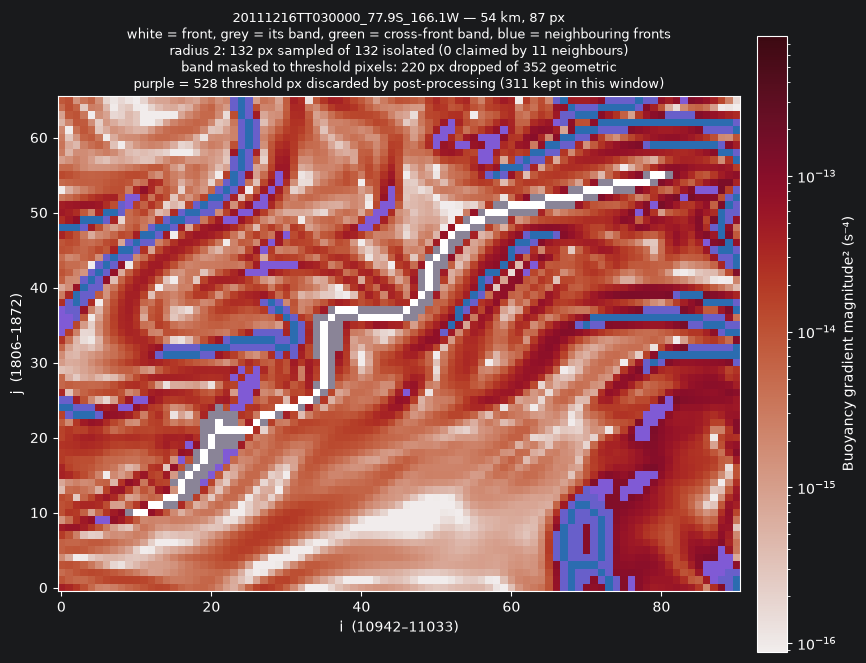

In [10]:
plot_front_dilation(store, 20, show_cross=False, show_dilation=True)# 10)

<Axes: title={'center': '20111216TT030000_46.0S_123.1E — 91 km, 53 px\nwhite = front, grey = its band, green = cross-front band, blue = neighbouring fronts\nradius 2: 57 px sampled of 65 isolated (8 claimed by 4 neighbours)\nband masked to threshold pixels: 150 px dropped of 215 geometric\npurple = 166 threshold px discarded by post-processing (91 kept in this window)'}, xlabel='i  (7709–7756)', ylabel='j  (5200–5242)'>

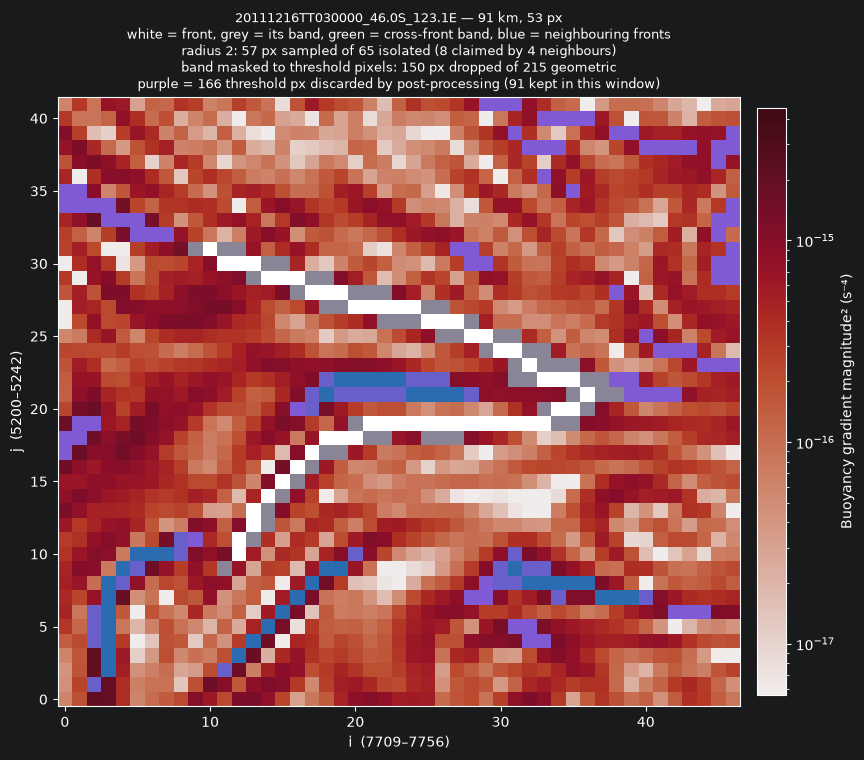

In [11]:
plot_front_dilation(store, 42920, show_cross=False, show_dilation=True)

In [12]:
fronts[fronts["length_km"] == fronts["length_km"].max()].label

79125    77850
Name: label, dtype: int32

In [13]:
store

In [14]:
store.geometry(DATE)

,label,name,time,npix,y0,y1,x0,x1,centroid_lat,centroid_lon,length_km,orientation,num_branches,lat_min,lat_max,lon_min,lon_max,mean_curvature,curvature_direction
0,7657,20111216TT030000_69.5S_148.5W,2011-12-16T03:00:00,11,2949,2957,11973,11983,-69.468132,-148.466858,9.996786,53.288158,0,-69.489700,-69.437782,-148.552078,-148.364578,0.044616,-0.044616
1,7658,20111216TT030000_69.5S_133.6W,2011-12-16T03:00:00,17,2949,2956,12684,12698,-69.461784,-133.626831,14.542251,83.917488,0,-69.489700,-69.445206,-133.739578,-133.468750,0.232116,0.055290
2,7659,20111216TT030000_69.4S_125.7W,2011-12-16T03:00:00,16,2949,2965,13064,13073,-69.434052,-125.729172,14.877590,29.407513,0,-69.489700,-69.378334,-125.822914,-125.656250,0.021010,-0.015278
3,7660,20111216TT030000_69.5S_101.6W,2011-12-16T03:00:00,9,2949,2954,14223,14229,-69.471581,-101.642365,7.705370,70.620956,0,-69.489700,-69.460045,-101.677086,-101.572914,NaN,NaN
4,7661,20111216TT030000_69.5S_50.6W,2011-12-16T03:00:00,9,2949,2952,16673,16682,-69.479820,-50.552086,7.308328,73.902130,0,-69.489700,-69.474876,-50.635418,-50.468750,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127622,126320,20111216TT030000_68.5N_112.4W,2011-12-16T03:00:00,38,12742,12749,13842,13877,68.485840,-112.431099,34.382961,78.145515,3,68.460220,68.501869,-112.790871,-112.048058,0.454082,0.034449
127623,126321,20111216TT030000_69.9N_96.2W,2011-12-16T03:00:00,21,12742,12762,14577,14585,69.859726,-96.164848,21.535700,12.692701,0,69.777008,69.937912,-96.253418,-96.015732,0.048044,-0.039872
127624,126322,20111216TT030000_69.4N_61.4W,2011-12-16T03:00:00,190,12742,12803,15998,16053,69.438545,-61.358677,186.151077,18.176746,17,69.206940,69.743187,-61.864407,-60.601711,0.297766,-0.008099
127625,126323,20111216TT030000_68.6N_54.8W,2011-12-16T03:00:00,37,12742,12758,16306,16338,68.645119,-54.831646,35.278492,64.090637,0,68.561798,68.746284,-55.078091,-54.500397,0.360113,0.124049


In [15]:
plot_front_dilation(store, 47356)

KeyboardInterrupt: 

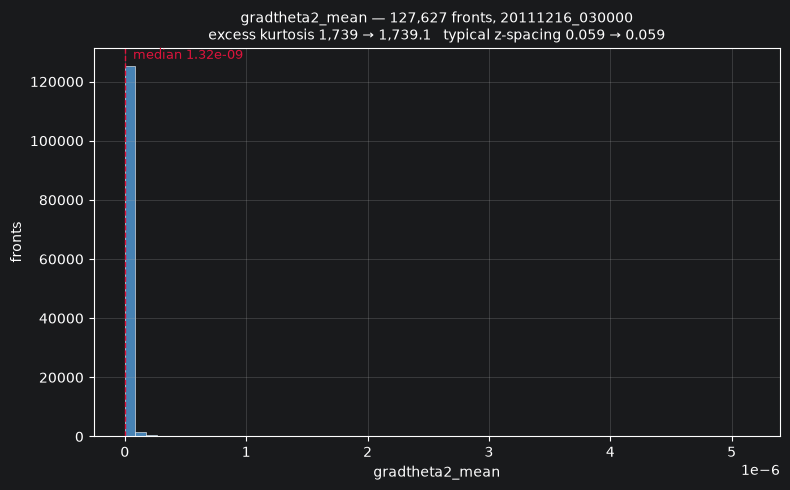

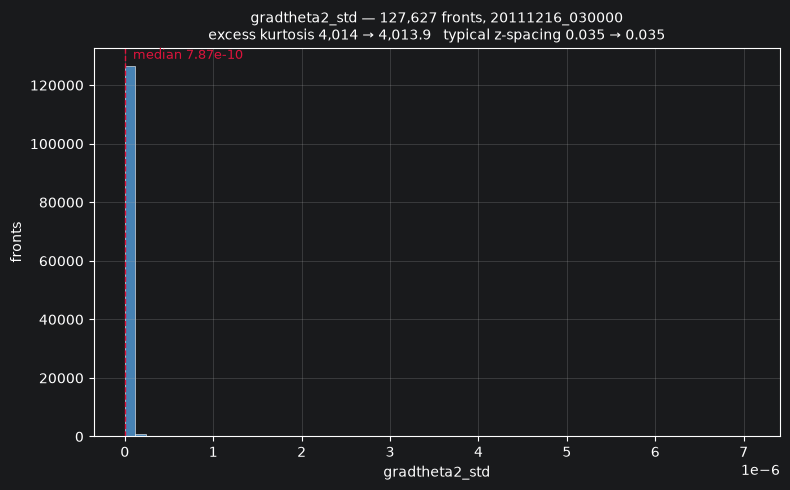

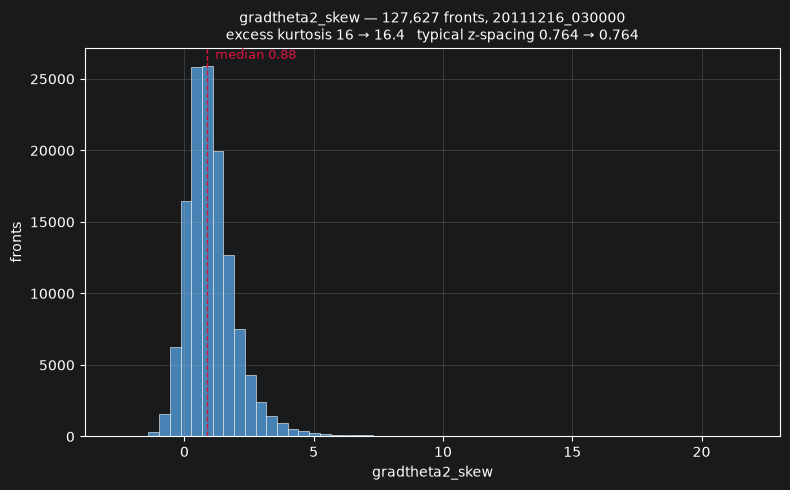

In [65]:
# plot_cols = [("gradeta2_mean", False),
#              ("density_mean", False), ("Salt_mean", False),
#              ("gradtheta2_mean", False), ("turner_angle_mean", False),
#              ("rossby_number_mean", False), ("oceTAUX_mean", False),
#              ("okubo_weiss_mean", True), ("gradsalt2_mean", True),
#              ("wind_stress_curl_mean", False)]

plot_cols = [("gradtheta2_mean", False),("gradtheta2_std", False),("gradtheta2_skew", False)]

# ("length_km", False), ("mean_curvature", False), ("gradb2_mean", True), ("gradb2_std", True), ("gradb2_skew", False), ("density_std", False), ("density_skew", False)
for c in plot_cols:
    plot_property_distribution(store, DATE, c[0], log=c[1], bins=60, ax=None)

column                             n          min          max      <=0  log?
oceTAUX_mean                 127,627   -3.069e+00    8.929e-01   56,661  no
oceTAUX_std                  127,627    2.308e-06    5.941e+00        0  yes
oceTAUX_skew                 127,627   -8.370e+00    1.232e+01   62,768  no
oceTAUY_mean                 127,627   -2.050e+00    1.093e+00   66,240  no
oceTAUY_std                  127,627    8.793e-07    1.076e+00        0  yes
oceTAUY_skew                 127,627   -1.088e+01    6.142e+00   63,821  no
rossby_number_mean           127,615   -3.753e+02    2.095e+02   45,274  no
rossby_number_std            127,615    0.000e+00    1.212e+03       18  no
rossby_number_skew           127,572   -6.845e+00    6.435e+00   44,708  no
turner_angle_mean            127,627   -8.952e+01    8.986e+01   71,471  no
turner_angle_std             127,627    1.414e-04    7.676e+01        0  yes
turner_angle_skew            127,627   -2.674e+01    4.175e+01   62,990  no
gradthe

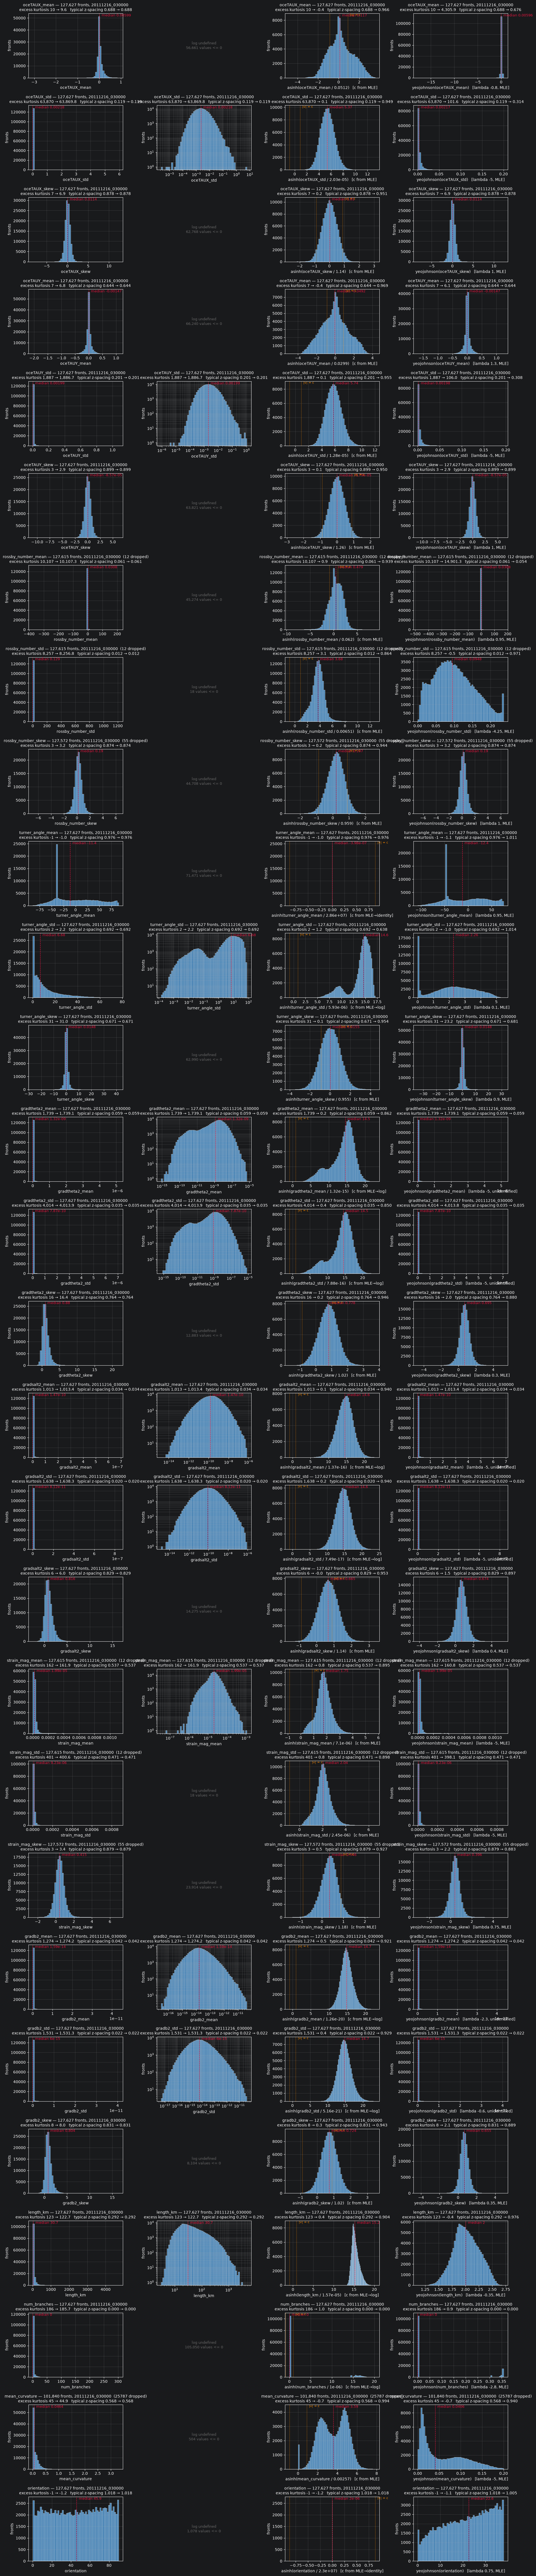

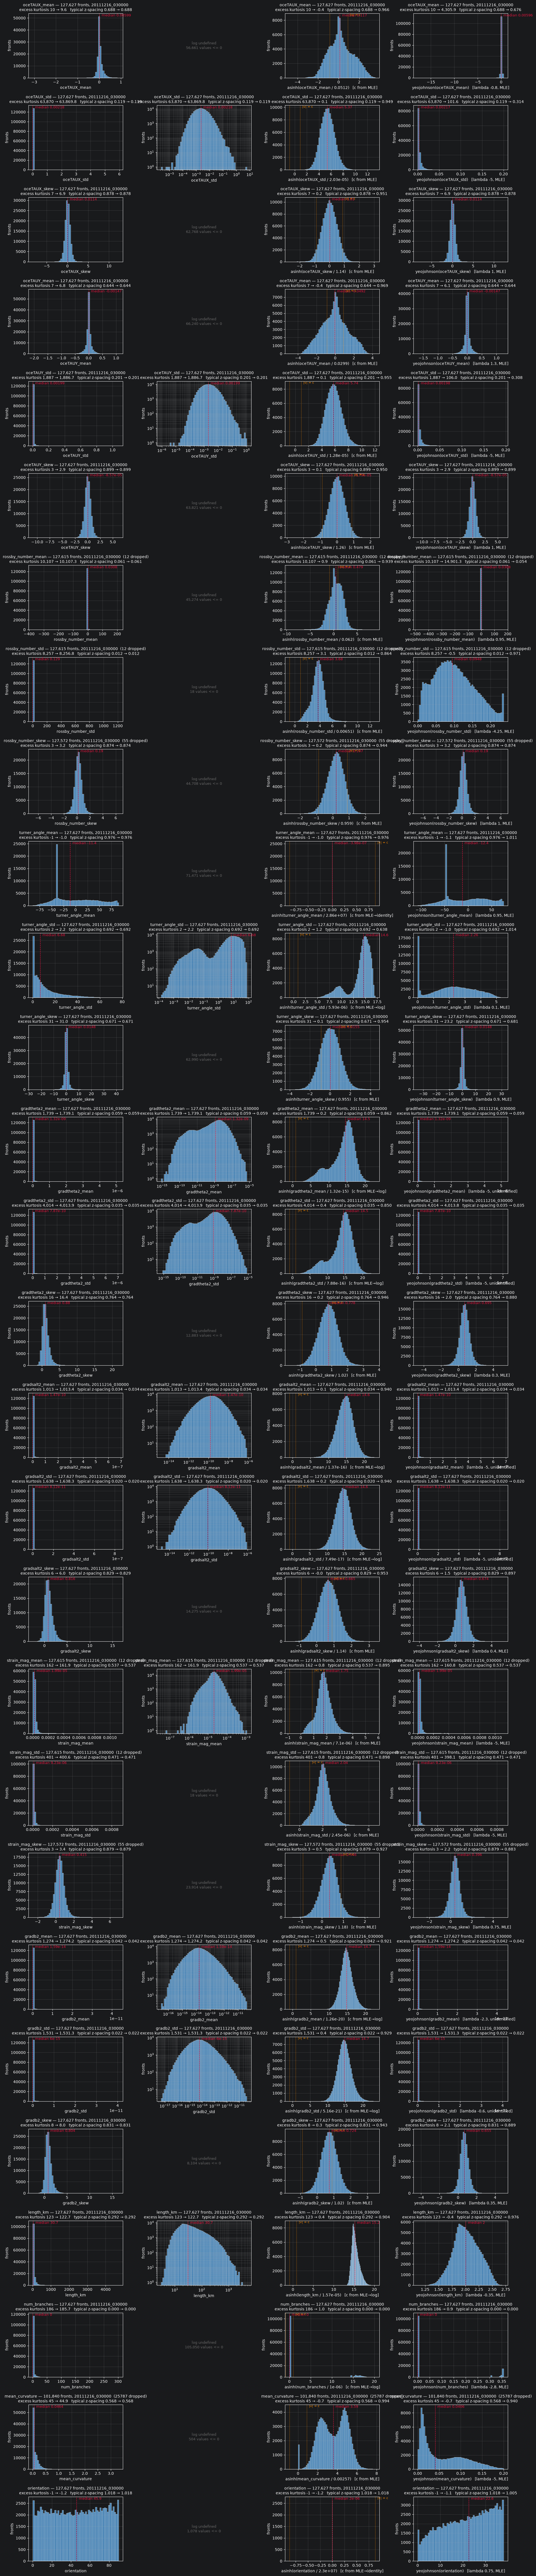

In [74]:
def compare_transforms(store, date, cols, bins=60, panel=(4.8, 3.3)):
    """One row per feature, one column per transform.

    log is skipped for a column with any non-positive value -- dropping those
    fronts would compare a different population in that panel.  The IHS
    crossover is fitted per column, so its panel title carries the regime the
    fit landed in.
    """
    cols = list(cols)
    frame = store.fronts(date, cross=True)

    print(f"{'column':26s} {'n':>9s} {'min':>12s} {'max':>12s} {'<=0':>8s}  log?")
    for col in cols:
        v = frame[col].to_numpy(float)
        v = v[np.isfinite(v)]
        n_bad = int((v <= 0).sum())
        print(f"{col:26s} {v.size:9,d} {v.min():12.3e} {v.max():12.3e} "
              f"{n_bad:8,d}  {'yes' if not n_bad else 'no'}")

    transforms = ("linear", "log", "asinh", "yeojohnson")
    fig, axes = plt.subplots(len(cols), len(transforms), squeeze=False,
                             figsize=(len(transforms) * panel[0],
                                      len(cols) * panel[1]))
    for row, col in enumerate(cols):
        v = frame[col].to_numpy(float)
        v = v[np.isfinite(v)]
        positive = not (v <= 0).any()
        for ax, name in zip(axes[row], transforms):
            if name == "log" and not positive:
                ax.axis("off")
                ax.text(0.5, 0.5, f"log undefined\n{int((v <= 0).sum()):,} "
                        f"values <= 0", ha="center", va="center",
                        fontsize=9, color="0.4", transform=ax.transAxes)
                continue
            plot_property_distribution(store, date, col, transform=name,
                                       bins=bins, ax=ax)
    fig.tight_layout()
    return fig


PLOT_COLS = [
    "oceTAUX_mean", "oceTAUX_std", "oceTAUX_skew",
    "oceTAUY_mean", "oceTAUY_std", "oceTAUY_skew",
    "rossby_number_mean", "rossby_number_std", "rossby_number_skew",
    "turner_angle_mean", "turner_angle_std", "turner_angle_skew",
    "gradtheta2_mean", "gradtheta2_std", "gradtheta2_skew",
    "gradsalt2_mean", "gradsalt2_std", "gradsalt2_skew",
    "strain_mag_mean", "strain_mag_std", "strain_mag_skew",
    "gradb2_mean", "gradb2_std", "gradb2_skew",
    "length_km", "num_branches", "mean_curvature", "orientation",
]

compare_transforms(store, DATE, PLOT_COLS)

# compare_transforms(store, DATE,
#                    ["gradtheta2_mean", "gradtheta2_std", "gradtheta2_skew",
#                     "rossby_number_mean"]);

<Axes: title={'center': 'rossby_number_mean — 127,615 fronts, 20111216_030000  (12 dropped)\nexcess kurtosis 10,107 → 1.1   typical z-spacing 0.061 → 0.934'}, xlabel='asinh(rossby_number_mean / 0.0671)   [c from MLE]', ylabel='fronts'>

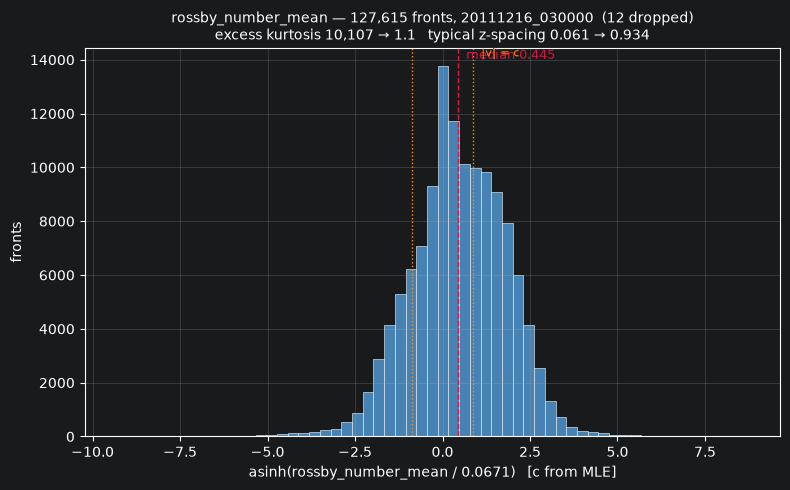

In [61]:
plot_property_distribution(store, DATE, "rossby_number_mean", False,
                           transform="asinh")

<Axes: title={'center': 'wind_stress_curl_mean — 127,625 fronts, 20111216_030000  (2 dropped)\nexcess kurtosis 2,396 → -0.0   typical z-spacing 0.196 → 0.956'}, xlabel='asinh(wind_stress_curl_mean / 2.3e-07)   [c from MLE]', ylabel='fronts'>

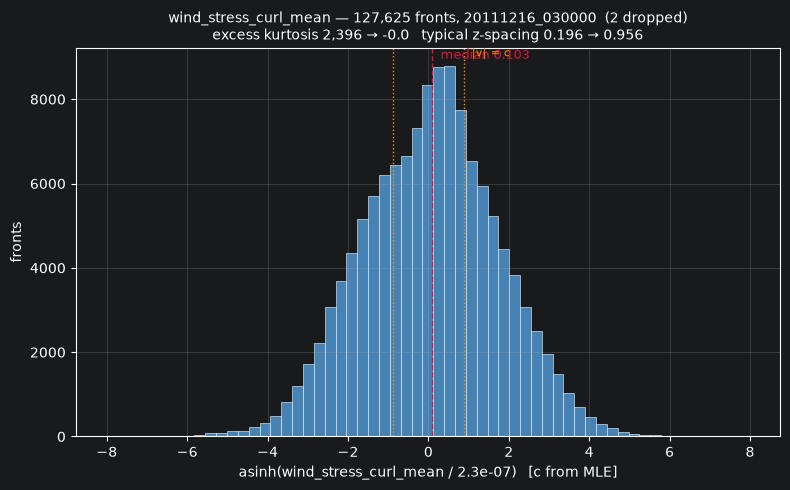

In [62]:
plot_property_distribution(store, DATE, "wind_stress_curl_mean", False,
                           transform="asinh")

<Axes: title={'center': 'okubo_weiss_mean — 127,615 fronts, 20111216_030000  (12 dropped)\nexcess kurtosis 42,204 → 2.4   typical z-spacing 0.059 → 0.844'}, xlabel='asinh(okubo_weiss_mean / 1.03e-10)   [c from MLE]', ylabel='fronts'>

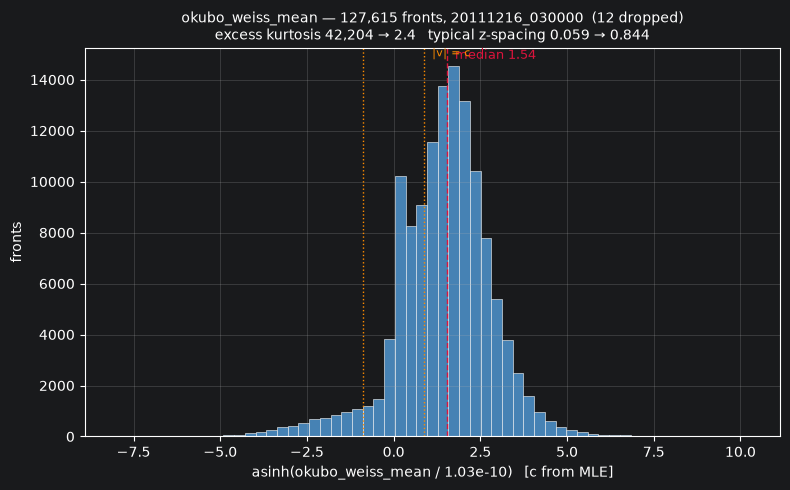

In [63]:
plot_property_distribution(store, DATE, "okubo_weiss_mean", False,
                           transform="asinh")

In [13]:
fronts.columns

Index(['label', 'name', 'time', 'npix', 'y0', 'y1', 'x0', 'x1', 'centroid_lat',
       'centroid_lon',
       ...
       'cross_density_median', 'cross_density_p25', 'cross_density_p75',
       'cross_density_p90', 'cross_buoyancy_mean', 'cross_buoyancy_std',
       'cross_buoyancy_median', 'cross_buoyancy_p25', 'cross_buoyancy_p75',
       'cross_buoyancy_p90'],
      dtype='str', length=117)

In [14]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm, Normalize

R_EARTH_KM = 6371.0


def _cell_area_km2(lat_edges, lon_edges):
    """Area of each lat/lon box.  Equal-degree cells are not equal-area."""
    dlon = np.deg2rad(np.diff(lon_edges))
    dsin = np.diff(np.sin(np.deg2rad(lat_edges)))
    return R_EARTH_KM ** 2 * np.outer(dsin, dlon)


def plot_front_map(fronts, value=None, resolution=2.0, per_area=True,
                   log=True, projection=None, cmap="magma", ax=None,
                   vmin=None, vmax=None):
    """Binned map of front centroids on the globe.

    Parameters
    ----------
    fronts : pandas.DataFrame
        Output of ``store.fronts(date)`` or ``store.dataset()``.  Needs
        ``centroid_lat`` and ``centroid_lon``.
    value : str, optional
        Column to sum in each cell, e.g. ``'length_km'``.  Default counts
        fronts.
    resolution : float
        Bin size in degrees.
    per_area : bool
        Divide by cell area, giving a density per 1000 km^2.  Equal-degree
        cells shrink towards the poles, so raw counts understate polar density
        by a factor of ~5 at 78 degrees.
    log : bool
        Log colour scale.  Empty cells are masked either way.
    projection : cartopy CRS, optional
        Defaults to Robinson.

    Returns
    -------
    (matplotlib.axes.Axes, matplotlib.collections.QuadMesh)
    """
    lat = fronts["centroid_lat"].to_numpy(float)
    lon = fronts["centroid_lon"].to_numpy(float)
    ok = np.isfinite(lat) & np.isfinite(lon)
    weights = None
    if value is not None:
        w = fronts[value].to_numpy(float)
        ok &= np.isfinite(w)
        weights = w[ok]
    lat, lon = lat[ok], lon[ok]

    lat_edges = np.arange(-90, 90 + resolution, resolution)
    lon_edges = np.arange(-180, 180 + resolution, resolution)
    H, _, _ = np.histogram2d(lat, lon, bins=[lat_edges, lon_edges],
                             weights=weights)

    unit = "fronts" if value is None else value
    if per_area:
        H = H / (_cell_area_km2(lat_edges, lon_edges) / 1e3)
        unit += " / 1000 km$^2$"
    H = np.ma.masked_equal(H, 0)

    if ax is None:
        _, ax = plt.subplots(
            figsize=(13, 6.5),
            subplot_kw={"projection": projection or ccrs.Robinson()})
    norm = (LogNorm(vmin=vmin or H.min(), vmax=vmax or H.max()) if log
            else Normalize(vmin=vmin, vmax=vmax))
    mesh = ax.pcolormesh(lon_edges, lat_edges, H, transform=ccrs.PlateCarree(),
                         cmap=cmap, norm=norm, shading="flat")

    ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=2)
    ax.coastlines(linewidth=0.4, color="0.4", zorder=3)
    ax.gridlines(linewidth=0.3, color="0.7", alpha=0.5)
    ax.set_global()

    cb = ax.figure.colorbar(mesh, ax=ax, orientation="vertical",
                            shrink=0.72, pad=0.02,
                            extend="both" if (vmin or vmax) else "neither")
    cb.set_label(unit)
    ax.set_title(f"{len(lat):,} fronts, {resolution}° bins")
    ax.figure.tight_layout()
    return ax, mesh

(<GeoAxes: title={'center': '111,654 fronts, 1.0° bins'}>,
 <cartopy.mpl.geocollection.GeoQuadMesh at 0x43ee43cb0>)

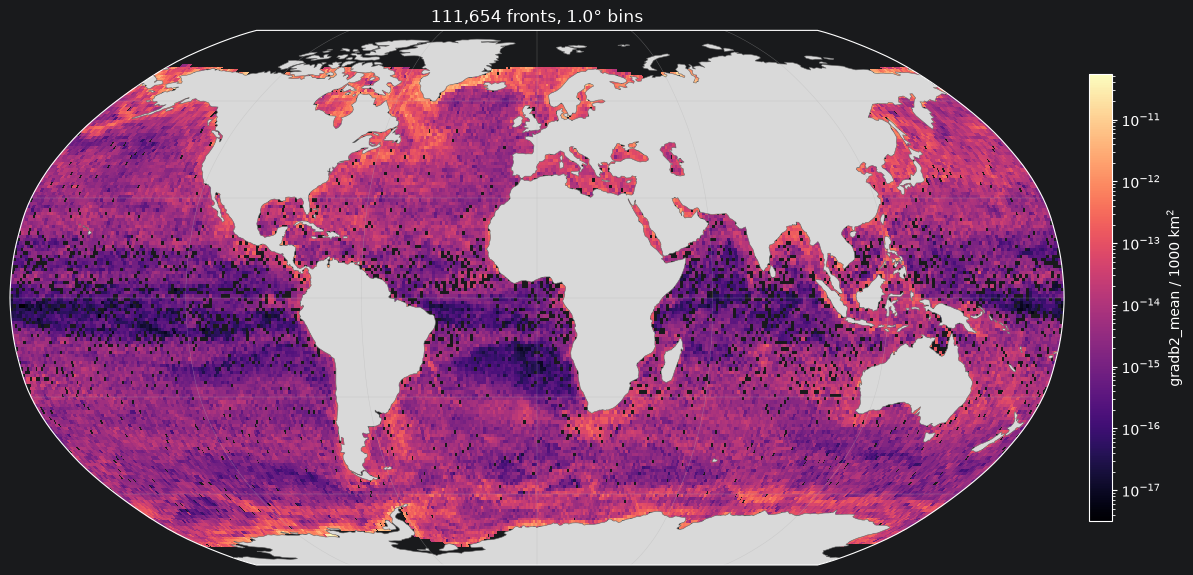

In [15]:
plot_front_map(store.fronts(DATE), value="gradb2_mean", resolution=1.0)

In [22]:
import numpy as np
import pandas as pd
from scipy import ndimage


def find_closed_fronts(store, date=None, window=None, min_hole=5,
                       min_circularity=0.5):
    """Closed fronts -- candidate eddies -- in a snapshot.

    A closed front encloses a background region that does not touch the frame.
    Circularity is 4*pi*A / P^2 over the LOOP's own boundary, not the whole
    connected component: a small ring hanging off a long meandering front is
    one component, so scoring the component would call every real ring
    non-circular.  1.0 is a perfect circle.

    window is (y0, y1, x0, x1).  The whole grid is 224 M px and this labels the
    background, so a window is strongly advised.
    """
    date = date or store.dates[0]
    binary = np.asarray(store.binary(date, window=window)
                        if window else store.binary(date)[:])
    y0, x0 = (window[0], window[2]) if window else (0, 0)
    labels = np.asarray(store.labels(date, window=window)
                        if window else store.labels(date)[:])

    bg, _ = ndimage.label(~binary)
    # A hole touching the frame is open water, not an enclosure.
    edge = set(np.unique(np.r_[bg[0], bg[-1], bg[:, 0], bg[:, -1]]))

    rows = []
    for hid, area in enumerate(np.bincount(bg.ravel())):
        if hid == 0 or hid in edge or area < min_hole:
            continue
        hole = bg == hid
        loop = ndimage.binary_dilation(hole, np.ones((3, 3))) & binary
        perim = int(loop.sum())
        circ = 4 * np.pi * area / (perim ** 2) if perim else 0.0
        if circ < min_circularity:
            continue
        owners = np.unique(labels[loop])
        owners = owners[owners > 0]
        ys, xs = np.where(hole)
        rows.append({
            "label": int(owners[0]) if len(owners) == 1 else -1,
            "n_fronts": len(owners),
            "hole_px": int(area),
            "loop_px": perim,
            "circularity": round(float(circ), 3),
            "j": int(ys.mean()) + y0,
            "i": int(xs.mean()) + x0,
        })
    return (pd.DataFrame(rows)
            .sort_values("circularity", ascending=False)
            .reset_index(drop=True))

In [23]:
find_closed_fronts(store, window=(5600, 6300, 2400, 3100), min_hole=15)

,label,n_fronts,hole_px,loop_px,circularity,j,i
0,47356,1,17,16,0.834,5866,2805
1,49160,1,17,16,0.834,6022,2445
2,45808,1,19,17,0.826,5781,2776
3,47861,1,21,18,0.814,5934,2564
4,52991,1,30,22,0.779,6249,2473
5,46768,1,26,21,0.741,5836,2767
6,50521,1,16,17,0.696,6131,2659
7,46340,1,17,18,0.659,5795,2580
8,49219,1,30,24,0.654,5986,2759
9,47950,1,16,18,0.621,5895,3091
